In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Problem 2: Leukemia Diagnosis

In [2]:
# load the data
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/leukemia.csv'
data = pd.read_csv(url)
data.head()

,0,1,2,3,4,5,6,7,8,9,...,16054,16055,16056,16057,16058,16059,16060,16061,16062,label
0,-73.0,-69.0,-48.0,13.0,-86.0,-147.0,-65.0,-71.0,-32.0,100.0,...,352.0,-67.0,121.0,-5.0,-11.0,-21.0,-41.0,-967.0,-120.0,1
1,-16.0,-63.0,-97.0,-42.0,-91.0,-164.0,-53.0,-77.0,-17.0,122.0,...,244.0,-15.0,119.0,-32.0,4.0,-14.0,-28.0,-205.0,-31.0,1
2,4.0,-45.0,-112.0,-25.0,-85.0,-127.0,56.0,-110.0,81.0,41.0,...,163.0,-14.0,7.0,15.0,-8.0,-104.0,-36.0,-245.0,34.0,1
3,-31.0,-110.0,-20.0,-50.0,-115.0,-113.0,-17.0,-40.0,-17.0,80.0,...,625.0,18.0,59.0,-10.0,32.0,-2.0,10.0,-495.0,-37.0,1
4,-33.0,-39.0,-45.0,14.0,-56.0,-106.0,73.0,-34.0,18.0,64.0,...,398.0,38.0,215.0,-2.0,44.0,3.0,68.0,-293.0,-34.0,1


This dataset contains cancer gene-expression levels (16,063 genes, 198 samples) from the paper [*Multiclass cancer diagnosis using tumor gene expression signatures (Golub et all, 2001)*](http://cbcl.mit.edu/publications/ps/rifkin-pnas-2001.pdf)

Cancer classes are labelled as follows:


- 1: breast
- 2:  prostate
- 3:  lung
- 4:  collerectal
- 5:  lymphoma
- 6:  bladder
- 7:  melanoma
- 8:  uterus
- 9:  **leukemia**
- 10: renal
- 11: pancreas
- 12: ovary
- 13: meso
- 14: cns


Your goal is to train a regression model to classify cancers as either leukemia or not-leukemia

**Part 1:** Replace the `label` values with:

$$
\left\{ \begin{array}{ll} 1 & \mbox{ if cancer is leukemia}\\
0 & \mbox{ if cancer is not leukemia}. \end{array}\right.
$$

In [3]:
data.loc[data.label!=9, 'label']=0

In [4]:
data.loc[data.label==9, 'label']=1

In [10]:
data.label.value_counts()

0    168
1     30
Name: label, dtype: int64

**Part 2:** Define X and y from the DataFrame, and then split X and y into training and testing sets

In [5]:
X= data.drop('label', axis=1)
y = data.label

In [6]:
# train / test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)

**Part 3:** Use the training set to train a **Lasso regression model**. 
Plot the model's coefficients. How many coefficients are equal to 0?

In [14]:


from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import Lasso



# Lasso regularization
degree=1
alpha = 0.1

pipe = Pipeline(steps=[
    ('poly_features', PolynomialFeatures(degree=degree,include_bias=False)),
    ('scaler',StandardScaler()),
    ('reg', Lasso(alpha=alpha)) 
])

# fit the pipeline
pipe.fit(X_train,y_train)

Pipeline(steps=[('poly_features',
                 PolynomialFeatures(degree=1, include_bias=False)),
                ('scaler', StandardScaler()), ('reg', Lasso(alpha=0.1))])

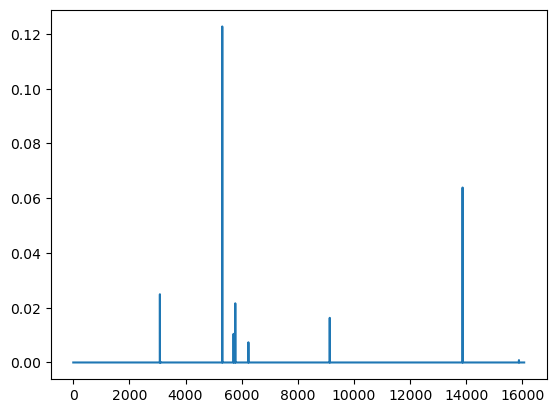

In [15]:
plt.plot(pipe['reg'].coef_)

In [16]:
pd.Series(pipe['reg'].coef_).value_counts()

-0.000000    16054
 0.000154        1
 0.000859        1
 0.021613        1
 0.007366        1
 0.063908        1
 0.122747        1
 0.010452        1
 0.016306        1
 0.024921        1
dtype: int64

16054 coeffs are set to zero

**Part 4:**  Use your regression model to classify all the cancers in the test set.  
Use the rule:

$$
\mbox{classify cancer as a }\left\{ \begin{array}{ll} 
\mbox{leukemia} & \mbox{ if y_test_pred}>0.5 \\
\mbox{not leukemia }5 & \mbox{ if predicted y_test_pred}\leq 0.5
\end{array}\right.
$$



In [17]:
y_test_pred = pipe.predict(X_test)

In [21]:
y_test_pred[y_test_pred>0.5]=1
y_test_pred[y_test_pred<=0.5]=0

How many cancers are misclassified? 

In [28]:
y_test!=y_test_pred

97     False
137    False
56     False
114    False
146    False
166    False
32     False
142    False
79     False
70     False
156    False
48     False
189    False
111    False
57     False
131    False
180    False
168    False
175    False
132    False
149    False
21     False
7      False
78     False
26     False
143    False
9      False
120    False
119    False
87      True
118    False
60     False
169    False
17     False
19     False
65     False
37     False
145    False
8      False
182    False
188    False
96     False
165    False
75     False
191    False
59     False
104    False
108    False
112    False
2      False
Name: label, dtype: bool

one

In [30]:
(y_test!=y_test_pred).sum()

1